# Lab Activity 1: Linear Regression Using the Boston Housing Dataset

This activity follows the required steps in the Linear Regression module.

**Objective:** Build a multiple linear regression model that predicts the median value of houses using the Boston Housing dataset from the `sklearn.datasets` library.

## How to Use This Notebook

Each code cell is followed by a **Sample Guide and Interpretation** section. These notes explain:

- what the code is doing;
- why the step is necessary;
- what students should examine in the output; and
- how the output may be interpreted in a written lab report.

Students should still run every code cell and write interpretations using the results produced on their own computer. Small differences may occur when a different software version or random state is used.

> **Unit reminder:** In this historical dataset, `MEDV` is expressed in thousands of US dollars. For example, a value of `24.0` represents approximately **$24,000** in the dataset's historical scale.


# Part 1 — Establish Objectives

## Problem

Create a linear regression model that predicts the median house value of a Boston neighborhood based on its housing and neighborhood characteristics.

## Guide Questions and Sample Answers

**1. What is the problem you want to solve?**  
Predict the median value of owner-occupied houses in a Boston neighborhood.

**2. What is the dependent or target variable?**  
`MEDV` — the median value of owner-occupied houses.

**3. What are the independent or input variables?**  
The input variables are `CRIM`, `ZN`, `INDUS`, `CHAS`, `NOX`, `RM`, `AGE`, `DIS`, `RAD`, `TAX`, `PTRATIO`, `B`, and `LSTAT`.

# Part 2 — Collect and Preprocess Data

Load the Boston Housing dataset using scikit-learn.

- Older scikit-learn versions provide `load_boston()`.
- Newer versions use `fetch_openml()` from the same `sklearn.datasets` library because `load_boston()` was removed.

An internet connection may be required when `fetch_openml()` is used.

In [2]:
# Import the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


## Sample Guide and Interpretation — Importing Libraries

### What this cell does

This cell imports the Python libraries and scikit-learn classes needed for the activity:

- `NumPy` supports numerical calculations.
- `pandas` stores and manipulates the dataset in tables called DataFrames.
- `matplotlib` and `seaborn` create graphs for exploratory data analysis.
- `train_test_split` divides the dataset into training and testing subsets.
- `StandardScaler` standardizes the input variables.
- `LinearRegression` creates the regression model.
- `mean_squared_error` and `r2_score` evaluate the model.

### What to observe

The message **“Libraries imported successfully.”** confirms that the required packages are available and the cell ran without an import error.

### Sample interpretation

> The required Python libraries were imported successfully. These libraries will be used for data handling, visualization, preprocessing, model construction, and evaluation.


In [3]:
# Load the Boston Housing dataset from sklearn.datasets
try:
    # Works with older versions of scikit-learn
    from sklearn.datasets import load_boston

    boston = load_boston()
    X = pd.DataFrame(boston.data, columns=boston.feature_names)
    y = pd.Series(boston.target, name="MEDV")
    data_source = "sklearn.datasets.load_boston"

except ImportError:
    # Compatibility method for newer versions of scikit-learn
    from sklearn.datasets import fetch_openml

    boston = fetch_openml(
        name="boston",
        version=1,
        as_frame=True
    )

    X = boston.data.copy()
    X = X.apply(pd.to_numeric, errors="coerce")
    y = pd.to_numeric(boston.target, errors="coerce")
    y.name = "MEDV"
    data_source = "sklearn.datasets.fetch_openml"

# Combine the input and target variables into one DataFrame
df = X.copy()
df["MEDV"] = y

print("Data source:", data_source)
print("Dataset shape:", df.shape)
df.head()

Data source: sklearn.datasets.fetch_openml
Dataset shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## Sample Guide and Interpretation — Loading the Dataset

### What this cell does

The cell loads the Boston Housing dataset from `sklearn.datasets`.

- It first attempts to use `load_boston()`, which is available only in older scikit-learn versions.
- When `load_boston()` is unavailable, it uses `fetch_openml()` from `sklearn.datasets`.
- The independent variables are stored in `X`.
- The dependent variable is stored in `y`.
- The input and target variables are combined into the DataFrame `df`.
- `df.head()` displays the first five rows so the dataset can be inspected.

### What to observe

The output shows:

- **Data source:** `sklearn.datasets.fetch_openml`
- **Dataset shape:** `(506, 14)`

This means the dataset contains **506 observations** and **14 columns**. Thirteen columns are input variables, while `MEDV` is the target variable.

### Sample interpretation

> The Boston Housing dataset was loaded successfully from scikit-learn. It contains 506 observations and 14 variables. The first 13 variables describe neighborhood or housing characteristics, while `MEDV` is the median house value to be predicted. The first five rows confirm that the dataset contains numerical values suitable for regression analysis.


In [4]:
# Display basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


## Sample Guide and Interpretation — Inspecting Dataset Information

### What this cell does

`df.info()` summarizes the structure of the DataFrame. It reports:

- the number of rows;
- the names of the columns;
- the number of non-null values in every column;
- the data type of each variable; and
- the approximate memory used by the DataFrame.

### What to observe

The output reports:

- **506 entries**
- **14 columns**
- **506 non-null values in every column**
- **12 `float64` columns and 2 `int64` columns**

The two integer columns are `CHAS` and `RAD`. All remaining columns are stored as decimal numbers.

### Sample interpretation

> The dataset contains 506 complete observations and 14 numerical columns. Every column has 506 non-null entries, which suggests that the dataset has no missing values. Since all variables are numerical, they can be used directly in the linear regression workflow after the required preprocessing.


# Part 3 — Preprocess Data and Perform EDA

Complete the required preprocessing and exploratory data analysis:

1. Check and handle missing values.
2. Check whether categorical variables need encoding.
3. Review value counts.
4. Examine descriptive statistics and data distributions.
5. Check correlations among variables.
6. Scale numerical input variables after splitting the data.

In [5]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
display(missing_values)

# Handle missing values using the median when necessary
if missing_values.sum() > 0:
    df = df.fillna(df.median(numeric_only=True))
    print("Missing values were replaced with column medians.")
else:
    print("The dataset has no missing values.")

Missing values per column:


CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

The dataset has no missing values.


## Sample Guide and Interpretation — Checking Missing Values

### What this cell does

The cell counts missing values in each column using `df.isnull().sum()`.

It also includes a conditional statement:

- If missing values exist, each missing numerical value is replaced with the median of its column.
- If no missing values exist, the DataFrame remains unchanged.

Median imputation is commonly used because the median is less affected by unusually high or low values than the mean.

### What to observe

Every column has a missing-value count of **0**, and the output states:

**“The dataset has no missing values.”**

### Sample interpretation

> No missing values were found in any of the 14 variables. Therefore, no imputation was necessary. The dataset can proceed to the next preprocessing step without removing rows or replacing values.


In [6]:
# Check the data types
display(df.dtypes.to_frame(name="Data Type"))

# All variables are numerical.
# CHAS is already encoded as 0 or 1, so no categorical encoding is required.
print("CHAS value counts:")
display(df["CHAS"].value_counts().sort_index())

,Data Type
CRIM,float64
ZN,float64
INDUS,float64
CHAS,int64
NOX,float64
RM,float64
AGE,float64
DIS,float64
RAD,int64
TAX,float64


CHAS value counts:


CHAS
0    471
1     35
Name: count, dtype: int64

## Sample Guide and Interpretation — Data Types and Encoding

### What this cell does

The first command displays the data type of every variable. The second command counts the values in `CHAS`.

`CHAS` is a binary indicator:

- `0` means the neighborhood does not bound the Charles River.
- `1` means the neighborhood bounds the Charles River.

Because it is already represented numerically as 0 and 1, no label encoding or one-hot encoding is needed.

### What to observe

The output shows that all variables are numerical. For `CHAS`:

- `0` appears **471 times**
- `1` appears **35 times**

### Sample interpretation

> All variables are already stored in numerical form, so categorical encoding is not required. The `CHAS` variable is binary and is already coded as 0 and 1. Most observations have `CHAS = 0`, while only 35 observations have `CHAS = 1`, showing that river-adjacent neighborhoods are much less common in the dataset.


In [7]:
# Display descriptive statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


## Sample Guide and Interpretation — Descriptive Statistics

### What this cell does

`df.describe().T` calculates summary statistics for every variable:

- `count` — number of observations;
- `mean` — arithmetic average;
- `std` — standard deviation;
- `min` and `max` — smallest and largest values;
- `25%`, `50%`, and `75%` — quartiles.

The transpose `.T` places variables in rows, making the table easier to read.

### What to observe

Examples from the output include:

- The average `MEDV` is approximately **22.53**, or about **$22,530** in the historical scale.
- The median `MEDV` is **21.20**.
- `MEDV` ranges from **5.0** to **50.0**.
- The average number of rooms (`RM`) is approximately **6.28**.
- `CRIM` has a mean of about **3.61** but a maximum near **88.98**, suggesting a strongly right-skewed distribution and possible extreme values.
- The variables use very different numerical scales. For example, `NOX` is below 1, while `TAX` is measured in the hundreds.

### Sample interpretation

> The descriptive statistics show substantial differences in the scales and distributions of the variables. The target variable has a mean of 22.53 and a median of 21.20, while its maximum value is 50.00. Some predictors, such as `CRIM`, have extreme maximum values relative to their medians. Because the predictors use different units and ranges, standardization will be applied before training the model.


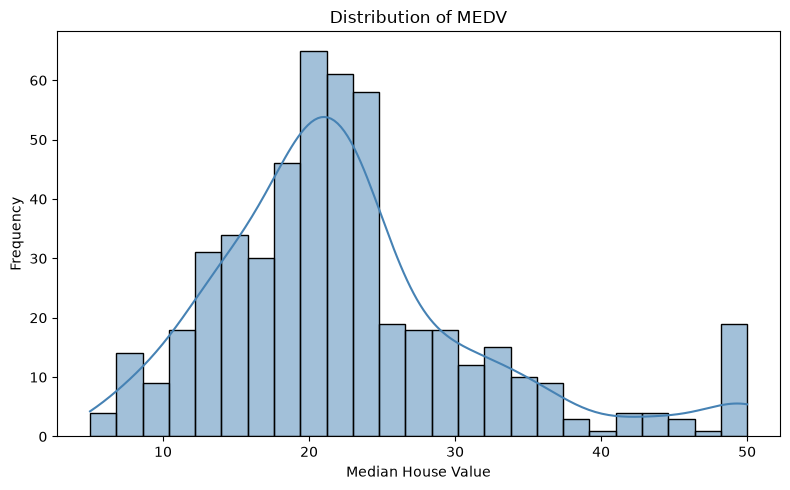

In [8]:
# Display the distribution of the target variable
plt.figure(figsize=(8, 5))
sns.histplot(df["MEDV"], bins=25, kde=True, color="steelblue")
plt.title("Distribution of MEDV")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Sample Guide and Interpretation — Target Distribution

### What this cell does

This cell creates a histogram of `MEDV`.

- The bars show how frequently different house-value ranges occur.
- The KDE curve provides a smooth estimate of the distribution.
- The graph helps identify skewness, unusual values, and possible limits in the target.

### What to observe

Most `MEDV` observations are concentrated roughly between **15 and 25**. The distribution is not perfectly symmetric, and there is a noticeable group of observations at the maximum value of **50**.

The pile-up at 50 suggests that the target was capped at that value in the historical dataset. A capped target can make it difficult for a linear model to learn the true values of the most expensive observations.

### Sample interpretation

> The distribution of `MEDV` is concentrated mainly in the lower and middle value ranges and is not perfectly normal. A visible concentration occurs at the maximum value of 50, indicating that the target is capped. This ceiling may reduce prediction accuracy for high-value observations because the true values above the cap are not available.


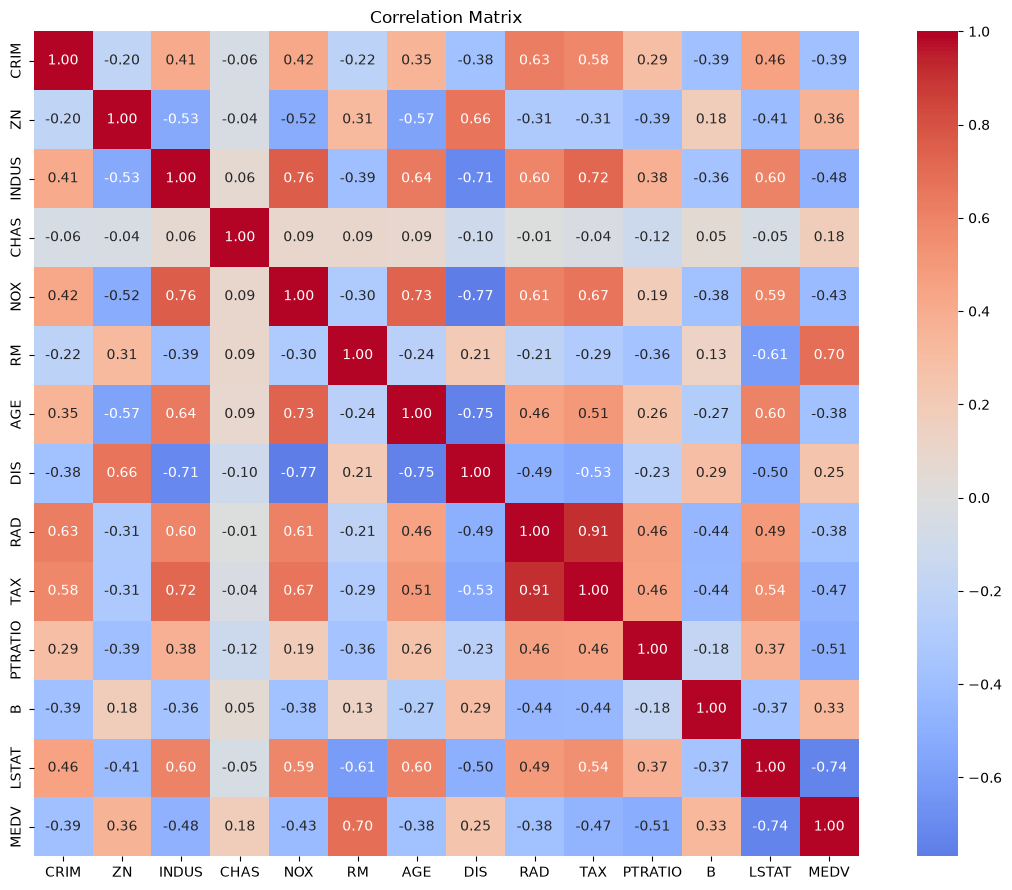

MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64

In [9]:
# Calculate and display the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0,
    square=True
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Show the correlation of each variable with MEDV
correlation_matrix["MEDV"].sort_values(ascending=False)

## Sample Guide and Interpretation — Correlation Analysis

### What this cell does

The correlation matrix measures the direction and strength of the linear relationship between pairs of numerical variables.

Correlation values range from `-1` to `+1`:

- A value near `+1` indicates a strong positive linear relationship.
- A value near `-1` indicates a strong negative linear relationship.
- A value near `0` indicates a weak linear relationship.

The sorted output focuses on each predictor's correlation with `MEDV`.

### What to observe

The strongest relationships with `MEDV` are:

- `RM`: **0.695** — a strong positive relationship
- `LSTAT`: **-0.738** — a strong negative relationship
- `PTRATIO`: **-0.508** — a moderate negative relationship
- `INDUS`: **-0.484**
- `TAX`: **-0.469**

### Sample interpretation

> `RM` has the strongest positive correlation with `MEDV`, suggesting that neighborhoods with more rooms per dwelling tend to have higher median house values. `LSTAT` has the strongest negative correlation, suggesting that higher values of `LSTAT` are associated with lower median house values. `PTRATIO`, `INDUS`, and `TAX` also have moderate negative relationships with the target. These correlations describe associations only and do not prove that any predictor causes changes in house value.

### Additional observation

Some independent variables are also strongly correlated with one another. This condition is called **multicollinearity** and may make individual regression coefficients harder to interpret, even when the overall model predicts reasonably well.


# Part 4 — Split the Data

Divide the dataset into:

- **80% training data**
- **20% testing data**

In [10]:
# Separate the independent variables and target variable
X = df.drop(columns=["MEDV"])
y = df["MEDV"]

# Split the dataset into 80% training and 20% testing subsets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training input shape:", X_train.shape)
print("Testing input shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training input shape: (404, 13)
Testing input shape: (102, 13)
Training target shape: (404,)
Testing target shape: (102,)


## Sample Guide and Interpretation — Train-Test Split

### What this cell does

The cell first separates:

- `X` — the 13 independent variables;
- `y` — the target variable `MEDV`.

It then divides the observations into:

- **80% training data**, used to fit the model;
- **20% testing data**, used to evaluate predictions on unseen observations.

`random_state=42` makes the split reproducible, meaning the same rows will be assigned to the same subsets each time the notebook is run.

### What to observe

The output shows:

- `X_train`: **404 rows and 13 columns**
- `X_test`: **102 rows and 13 columns**
- `y_train`: **404 target values**
- `y_test`: **102 target values**

### Sample interpretation

> The dataset was divided into 404 training observations and 102 testing observations, which corresponds to an 80/20 split. The model will learn from the training set and will be evaluated using the separate test set. Keeping the test set unseen during training provides a more realistic estimate of model performance on new data.


# Part 5 — Perform Linear Regression in Python

Standardize the numerical input variables using `StandardScaler`.

The scaler is fitted only on the training data and then applied to the testing data.

In [11]:
# Standardize the input variables
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Input variables were standardized successfully.")

Input variables were standardized successfully.


## Sample Guide and Interpretation — Standardizing Input Variables

### What this cell does

`StandardScaler` transforms every predictor so that, in the training data, it has approximately:

- a mean of `0`;
- a standard deviation of `1`.

The scaler is fitted using `X_train` only. The same training-set transformation is then applied to `X_test`.

This avoids **data leakage**, which would occur if information from the test set influenced preprocessing.

### What to observe

The message **“Input variables were standardized successfully.”** confirms that the transformation was completed.

The transformed arrays still have the same number of rows and columns as the original training and testing inputs, but their numerical scales have changed.

### Sample interpretation

> The independent variables were standardized because they use different units and ranges. The scaler was fitted only on the training data and then applied to the test data. This ensures that the test set remains independent and prevents information leakage.


# Part 6 — Build the Linear Regression Model

Import `LinearRegression` from `sklearn.linear_model` and train it using the training data.

In [12]:
# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Linear regression model trained successfully.")

Linear regression model trained successfully.


## Sample Guide and Interpretation — Training the Model

### What this cell does

The cell creates a `LinearRegression` object and trains it with:

- `X_train_scaled` as the standardized independent variables;
- `y_train` as the known target values.

During training, the algorithm estimates an intercept and one coefficient for each predictor. It selects values that minimize the squared differences between the actual and predicted target values in the training set.

### What to observe

The message **“Linear regression model trained successfully.”** confirms that model fitting was completed without an error.

### Sample interpretation

> A multiple linear regression model was trained using the 404 standardized training observations. The model learned a linear relationship between the 13 input variables and `MEDV`. Its performance must now be evaluated on the unseen testing data.


In [13]:
# Display the model coefficients
coefficients = pd.DataFrame({
    "Input Variable": X.columns,
    "Coefficient": model.coef_
})

display(coefficients)
print("Intercept:", model.intercept_)

,Input Variable,Coefficient
0,CRIM,-1.002135
1,ZN,0.696269
2,INDUS,0.278065
3,CHAS,0.718738
4,NOX,-2.022319
5,RM,3.145240
6,AGE,-0.176048
7,DIS,-3.081908
8,RAD,2.251407
9,TAX,-1.767014


Intercept: 22.796534653465343


## Sample Guide and Interpretation — Model Coefficients

### What this cell does

The cell displays the coefficient assigned to each standardized predictor and the model intercept.

Because the predictors were standardized, a coefficient represents the expected change in predicted `MEDV` for a **one-standard-deviation increase** in that predictor, while the other predictors are held constant.

- A positive coefficient increases the prediction.
- A negative coefficient decreases the prediction.
- A larger absolute coefficient indicates a stronger contribution within this fitted model.

### What to observe

Important coefficients include:

- `RM`: **+3.145**
- `LSTAT`: **-3.612**
- `DIS`: **-3.082**
- `RAD`: **+2.251**
- `PTRATIO`: **-2.038**
- `NOX`: **-2.022**

The intercept is approximately **22.797**.

### Sample interpretation

> Holding the other variables constant, `RM` has a strong positive coefficient, so a one-standard-deviation increase in average rooms is associated with an increase of about 3.15 units in predicted `MEDV`. `LSTAT` has the largest negative coefficient, indicating a decrease of about 3.61 units for a one-standard-deviation increase. The intercept of 22.80 is the predicted `MEDV` when all standardized predictors equal zero—that is, when every predictor is at its training-set mean.

### Important caution

Coefficient size should not be treated as proof of causation. In addition, correlations among predictors may influence both the size and direction of individual coefficients.


# Part 7 — Evaluate the Model

Evaluate the trained model on the testing data using:

- **Mean Squared Error (MSE)**
- **R-squared score ($R^2$)**

In [14]:
# Predict the target values of the testing data
y_pred = model.predict(X_test_scaled)

# Calculate the required evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")

Mean Squared Error: 24.2911
R-squared Score: 0.6688


## Sample Guide and Interpretation — Model Evaluation

### What this cell does

The model predicts `MEDV` for the 102 unseen testing observations. Two required metrics are then calculated:

- **Mean Squared Error (MSE):** the average of the squared prediction errors. Lower values indicate smaller errors.
- **R-squared (`R²`):** the proportion of variation in the target explained by the model on the test set.

### What to observe

The output reports:

- **MSE = 24.2911**
- **R² = 0.6688**

Since MSE is expressed in squared target units, it is not interpreted directly as an average dollar error. Its square root would be approximately 4.93 `MEDV` units, but RMSE is not required by the module.

### Sample interpretation

> The test MSE is 24.2911. The model's R-squared score is 0.6688, meaning that it explains approximately 66.88% of the variation in median house values in the testing set. The remaining 33.12% is not explained by this linear model and may be related to omitted variables, nonlinear relationships, unusual observations, or random variation. The result indicates moderate predictive performance, but the model is not perfectly accurate.


In [17]:
# Compare some actual and predicted values
results = pd.DataFrame({
    "Actual MEDV": y_test,
    "Predicted MEDV": y_pred
})

results.head(10)

,Actual MEDV,Predicted MEDV
173,23.6,28.996724
274,32.4,36.025565
491,13.6,14.816944
72,22.8,25.031979
452,16.1,18.769880
76,20.0,23.254429
316,17.8,17.662538
140,14.0,14.341190
471,19.6,23.013207
500,16.8,20.632456


## Sample Guide and Interpretation — Actual and Predicted Values

### What this cell does

This cell creates a table that places the actual test value beside the model's prediction. Comparing the two columns helps students see individual prediction errors.

The prediction error for an observation can be calculated as:

`Actual MEDV − Predicted MEDV`

- A positive result means the model underpredicted.
- A negative result means the model overpredicted.

### What to observe

Examples from the displayed rows include:

- Actual `23.6`, predicted approximately `29.00` — the model overpredicted.
- Actual `13.6`, predicted approximately `14.82` — the prediction is relatively close.
- Actual `17.8`, predicted approximately `17.66` — the prediction is very close.
- Actual `16.8`, predicted approximately `20.63` — the model overpredicted.

### Sample interpretation

> The predictions are reasonably close for some observations but noticeably different for others. For example, the prediction for an actual value of 17.8 is close at approximately 17.66, while the prediction for an actual value of 23.6 is higher at approximately 29.00. This confirms that a model-level metric should be considered together with individual prediction errors.


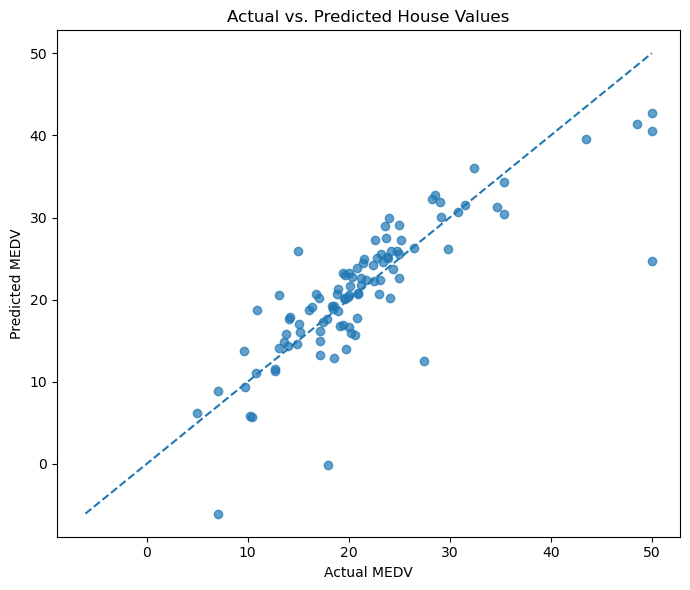

In [18]:
# Plot the actual and predicted values
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.7)

minimum_value = min(y_test.min(), y_pred.min())
maximum_value = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)

plt.title("Actual vs. Predicted House Values")
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.tight_layout()
plt.show()

## Sample Guide and Interpretation — Actual vs. Predicted Plot

### What this cell does

The scatter plot compares:

- actual `MEDV` values on the horizontal axis;
- predicted `MEDV` values on the vertical axis.

The dashed diagonal line represents perfect predictions, where:

`Predicted MEDV = Actual MEDV`

Points close to the line indicate accurate predictions. Points far from the line indicate larger errors.

### What to observe

Many points are located near the dashed line, especially in the middle value range. However, some points are noticeably far from it. At higher actual values, the model often predicts lower values than observed, indicating difficulty modeling expensive neighborhoods.

### Sample interpretation

> The actual-versus-predicted plot shows a clear positive relationship, which means the model generally assigns higher predictions to observations with higher actual values. Many points are near the perfect-prediction line, but the spread around the line shows that errors remain. The model appears less accurate for some high-value observations, which is consistent with the dataset's capped target and the limitations of a purely linear model.


# Part 8 — Sample Conclusion and Student Reflection

## Sample Conclusion

> This activity developed a multiple linear regression model for predicting `MEDV` using 13 Boston Housing input variables. The dataset contained 506 observations and no missing values. All variables were numerical, so categorical encoding was not required. Exploratory analysis showed that `RM` had the strongest positive correlation with `MEDV`, while `LSTAT` had the strongest negative correlation. The data were divided into 404 training observations and 102 testing observations, and the predictors were standardized using statistics learned only from the training set.
>
> The model produced a Mean Squared Error of **24.2911** and an R-squared score of **0.6688**. Therefore, it explained approximately **66.88%** of the variation in the test-set house values. The actual-versus-predicted plot showed that many estimates were reasonably close, but larger errors occurred for some observations, especially toward the higher end of the target range. The model could potentially be improved by examining outliers, testing nonlinear features, selecting predictors, or comparing linear regression with other regression algorithms.